<a href="https://colab.research.google.com/github/anggaa0519/data-science-2026/blob/main/Pertemuan9_Angga_Anggieanie_250401020172.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Pertemuan 9 — Algoritma Klasifikasi (Bagian 1)
## Pipeline Klasifikasi: Logistic Regression & Decision Tree

| | |
|---|---|
| **Nama** | Angga Anggieanie |
| **NIM** | 250401020172 |
| **Kelas** | IF401 |
| **Mata Kuliah** | Data Science |
| **Pertemuan** | 9 — Algoritma Klasifikasi (Bagian 1) |




## Langkah 1 — Load & EDA Singkat

Dataset **Breast Cancer Wisconsin** (bawaan scikit-learn) memuat 569 sampel sel tumor payudara dengan 30 fitur numerik (ukuran, tekstur, kelengkungan sel). Target: 0 = Malignant (ganas), 1 = Benign (jinak). Ini adalah masalah **Binary Classification**.

In [13]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target   # 0 = Malignant, 1 = Benign

print('Shape:', X.shape)
print()
print('Distribusi target:')
dist = pd.Series(y).value_counts().sort_index()
print(pd.DataFrame({
    'Kelas': ['0 - Malignant (Ganas)', '1 - Benign (Jinak)'],
    'Jumlah': dist.values,
    'Proporsi': (dist.values / len(y)).round(3)
}))

Shape: (569, 30)

Distribusi target:
                   Kelas  Jumlah  Proporsi
0  0 - Malignant (Ganas)     212     0.373
1     1 - Benign (Jinak)     357     0.627


In [14]:
# Ringkasan statistik 5 fitur pertama
X.iloc[:, :5].describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness
count,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10
std,3.52,4.30,24.30,351.91,0.01
min,6.98,9.71,43.79,143.50,0.05
25%,11.70,16.17,75.17,420.30,0.09
50%,13.37,18.84,86.24,551.10,0.10
75%,15.78,21.80,104.10,782.70,0.11
max,28.11,39.28,188.50,2501.00,0.16


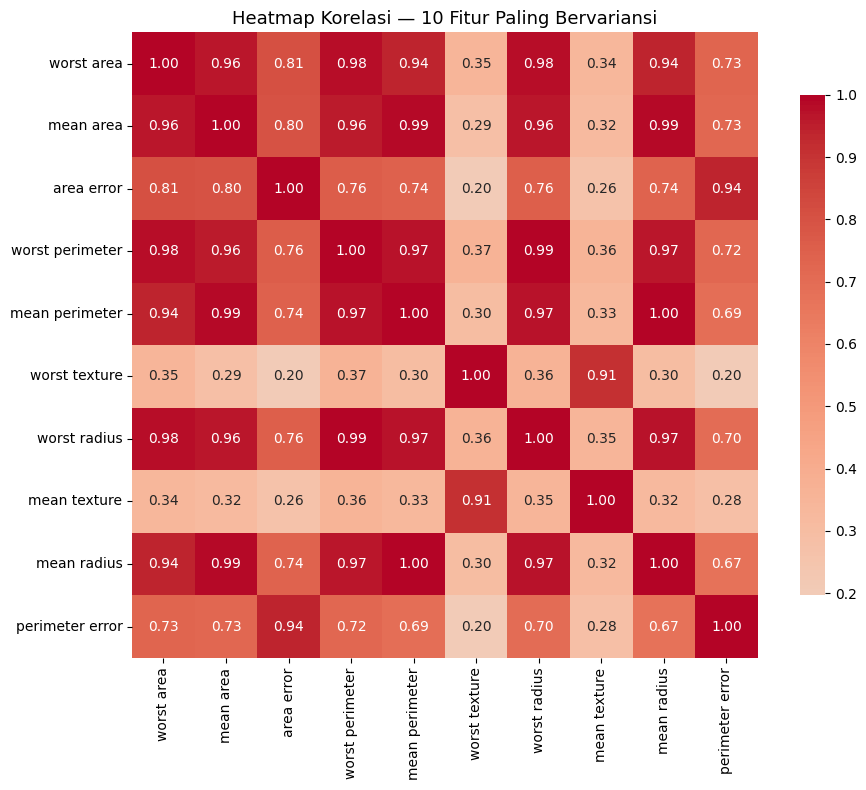

In [15]:
# Heatmap korelasi 10 fitur paling bervariansi
top10_features = X.var().nlargest(10).index
fig, ax = plt.subplots(figsize=(10, 8))
corr = X[top10_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap Korelasi — 10 Fitur Paling Bervariansi', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretasi:** Dataset berisi 569 sampel — 212 Malignant (37.3%) dan 357 Benign (62.7%). Kelas **tidak seimbang sempurna**, sehingga Accuracy saja tidak cukup — Recall menjadi metrik utama. Heatmap menunjukkan banyak fitur berkorelasi kuat satu sama lain (warna merah tua), karena fitur-fitur seperti `mean`, `worst`, dan `se` sering mengukur aspek serupa dari sel tumor. Kondisi ini (multikolinearitas) tidak menjadi masalah bagi Decision Tree, tetapi dapat mempengaruhi interpretasi koefisien Logistic Regression.

## Langkah 2 — Preprocessing

Train-Test Split 80:20 dengan `stratify=y` menjaga proporsi kelas di kedua subset. `StandardScaler` diperlukan untuk Logistic Regression (konvergensi gradient descent) tetapi **tidak diperlukan** untuk Decision Tree. Urutan anti-leakage dari Pertemuan 6 tetap diterapkan: split dulu, baru fit scaler pada training set.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape[0]} baris | Test: {X_test.shape[0]} baris')
print()
print('Proporsi kelas di Train:')
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
print(dict(train_dist.round(3)))
print('Proporsi kelas di Test:')
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()
print(dict(test_dist.round(3)))

# Scaling — fit HANYA pada train
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print()
print('Preprocessing selesai.')

Train: 455 baris | Test: 114 baris

Proporsi kelas di Train:
{0: np.float64(0.374), 1: np.float64(0.626)}
Proporsi kelas di Test:
{0: np.float64(0.368), 1: np.float64(0.632)}

Preprocessing selesai.


**Interpretasi:** Data terbagi 455 train / 114 test. Proporsi kelas di train dan test identik (≈37%:63%) berkat stratifikasi — penting agar distribusi target di test merepresentasikan kondisi nyata. Scaling menggunakan μ dan σ dari training set; test set hanya di-`transform()` untuk mencegah data leakage.

## Langkah 3 — Logistic Regression

`LogisticRegression` menggunakan fungsi **Sigmoid** σ(z) = 1/(1+e⁻ᶻ) untuk mengubah kombinasi linear fitur menjadi probabilitas. Parameter `max_iter=5000` memastikan konvergensi pada dataset 30 fitur. `predict_proba()` mengembalikan probabilitas sebelum threshold 0.5 diterapkan.

In [17]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train_s, y_train)
y_pred_log  = log_model.predict(X_test_s)
y_proba_log = log_model.predict_proba(X_test_s)[:, 1]

print(f'β₀ (intercept): {log_model.intercept_[0]:.3f}')
print()

# Koefisien terurut berdasarkan nilai absolut
coef_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Koefisien' : log_model.coef_[0]
}).assign(AbsKoef=lambda d: d['Koefisien'].abs())   .sort_values('AbsKoef', ascending=False).drop('AbsKoef', axis=1)

print('Top-10 fitur paling berpengaruh (Logistic Regression):')
print(coef_df.head(10).to_string(index=False))

β₀ (intercept): 0.302

Top-10 fitur paling berpengaruh (Logistic Regression):
               Fitur  Koefisien
       worst texture  -1.255088
        radius error  -1.082965
worst concave points  -0.953686
          worst area  -0.947756
        worst radius  -0.947616
      worst symmetry  -0.939181
          area error  -0.929104
     worst concavity  -0.823151
     worst perimeter  -0.763220
    worst smoothness  -0.746625


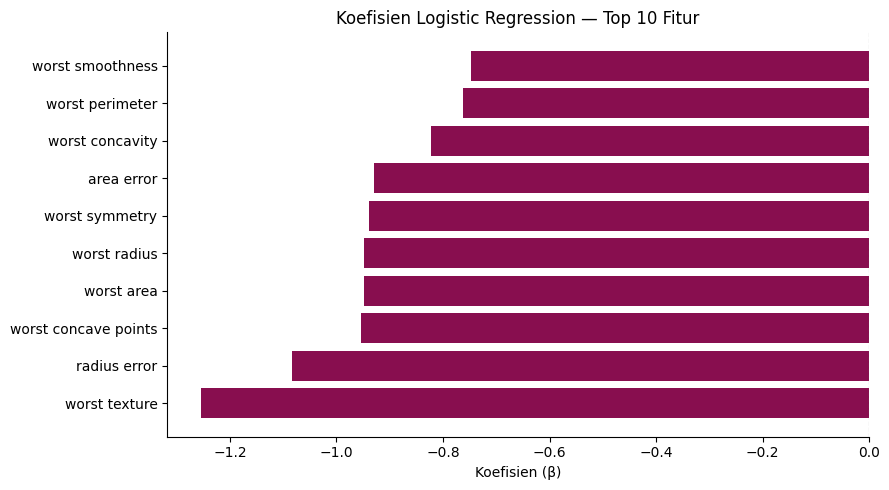

In [18]:
# Visualisasi koefisien top-10
top10 = coef_df.head(10).sort_values('Koefisien')
colors = ['#880E4F' if v < 0 else '#028090' for v in top10['Koefisien']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10['Fitur'], top10['Koefisien'], color=colors)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Koefisien Logistic Regression — Top 10 Fitur', fontsize=12)
ax.set_xlabel('Koefisien (β)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Interpretasi koefisien:** Koefisien **positif** → fitur itu meningkatkan peluang prediksi Benign (kelas 1); koefisien **negatif** → meningkatkan peluang prediksi Malignant (kelas 0). Fitur dengan koefisien absolut terbesar adalah yang paling berpengaruh terhadap keputusan model. Fitur bertanda negatif besar seperti `worst concave points` atau `worst perimeter` (ukuran ketidakaturan sel) adalah indikator kuat tumor ganas, sesuai dengan pengetahuan klinis.

## Langkah 4 — Decision Tree

`DecisionTreeClassifier` membangun aturan if-else bertingkat dengan memilih split yang memaksimalkan kemurnian node (**Gini Impurity** default). `max_depth=4` mencegah overfitting. Keunggulan utama: **tidak perlu scaling** dan hasilnya bisa divisualisasikan sebagai pohon yang dapat dibaca manusia.

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model = DecisionTreeClassifier(criterion='gini', max_depth=4,
                                     min_samples_leaf=5, random_state=42)
tree_model.fit(X_train, y_train)   # tanpa scaling!
y_pred_tree = tree_model.predict(X_test)

print('Decision Tree (max_depth=4) — Training selesai.')
print(f'Kedalaman aktual: {tree_model.get_depth()}')
print(f'Jumlah leaf nodes: {tree_model.get_n_leaves()}')

Decision Tree (max_depth=4) — Training selesai.
Kedalaman aktual: 4
Jumlah leaf nodes: 10


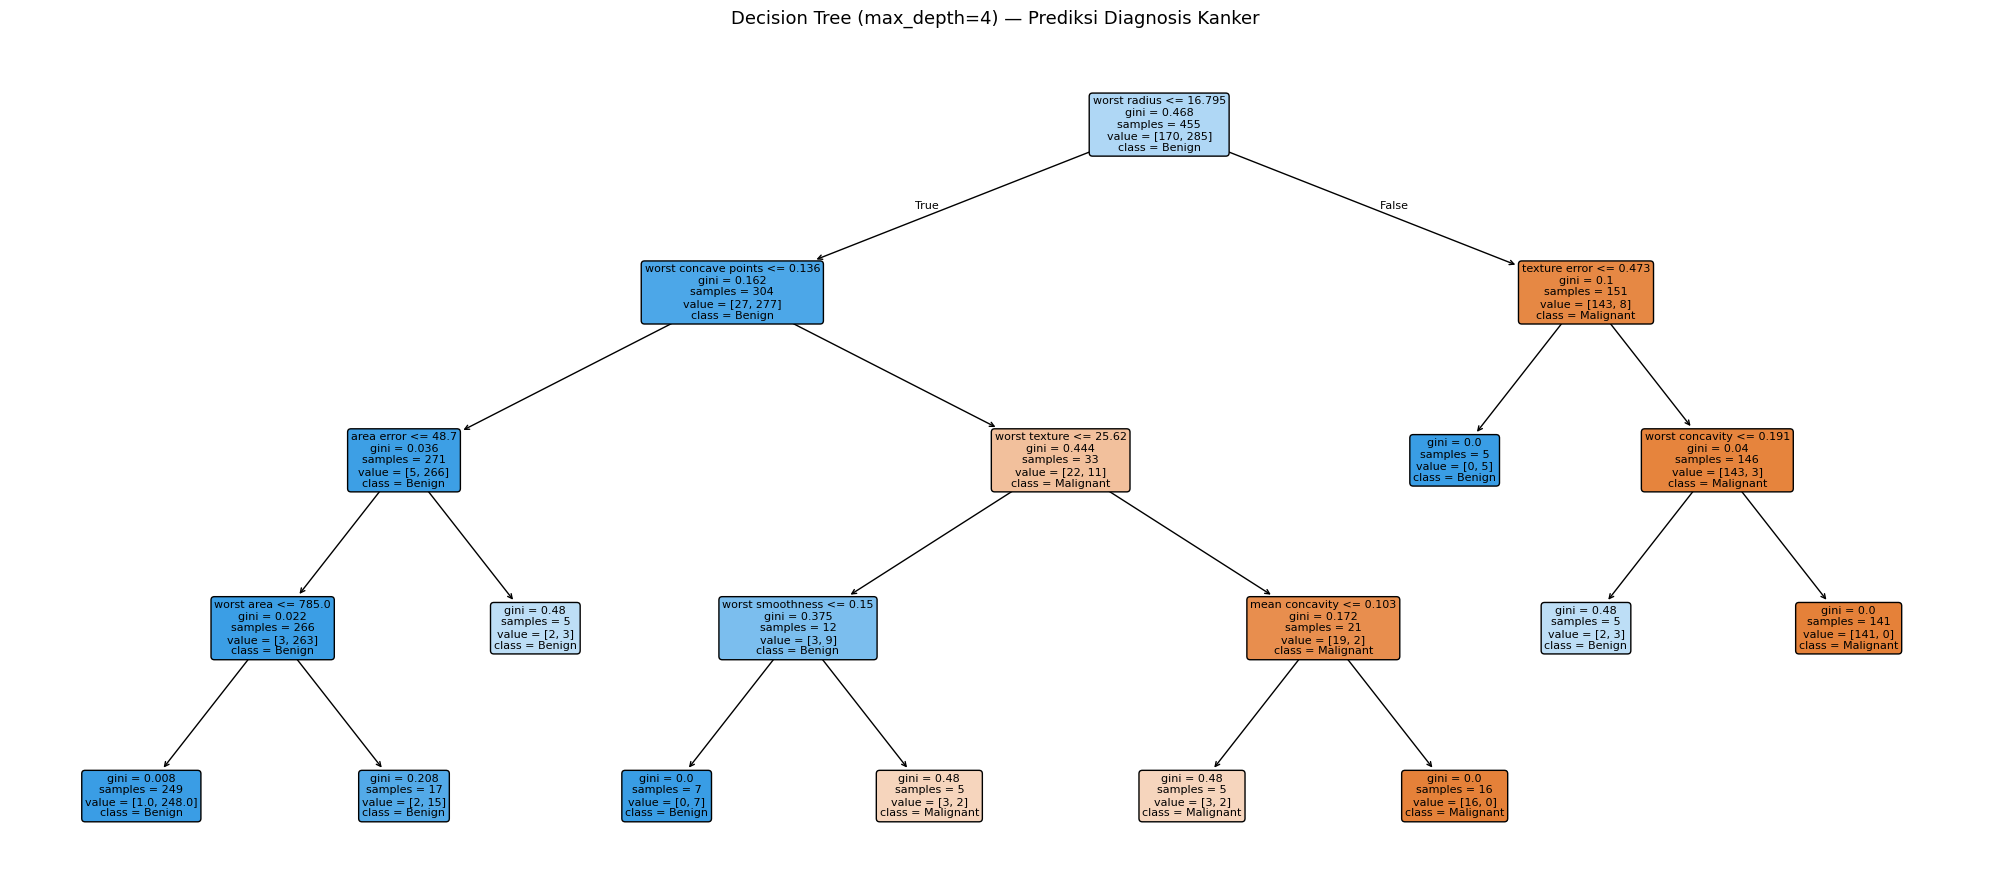

Pohon tersimpan sebagai decision_tree_viz.png


In [20]:
# Visualisasi pohon
fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(tree_model,
          feature_names=list(X.columns),
          class_names=['Malignant', 'Benign'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree (max_depth=4) — Prediksi Diagnosis Kanker',
             fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('decision_tree_viz.png', dpi=120, bbox_inches='tight')
plt.show()
print('Pohon tersimpan sebagai decision_tree_viz.png')

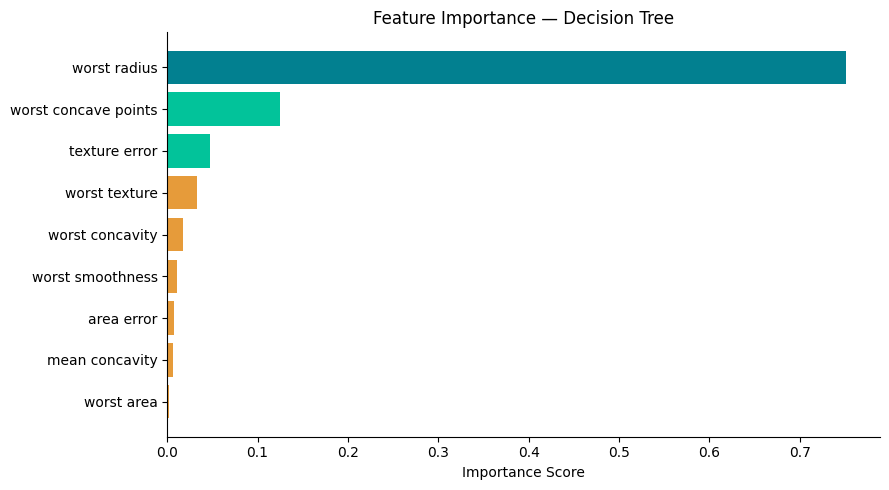

Top-5 fitur terpenting:
               Fitur  Importance
        worst radius    0.751145
worst concave points    0.124955
       texture error    0.046883
       worst texture    0.033095
     worst concavity    0.017573


In [21]:
# Feature Importance
importance_df = pd.DataFrame({
    'Fitur'      : X.columns,
    'Importance' : tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

top_imp = importance_df[importance_df['Importance'] > 0].head(10)
colors  = ['#028090' if i == 0 else '#02C39A' if i < 3 else '#E69B3A'
           for i in range(len(top_imp))]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_imp['Fitur'][::-1], top_imp['Importance'][::-1], color=colors[::-1])
ax.set_title('Feature Importance — Decision Tree', fontsize=12)
ax.set_xlabel('Importance Score')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Top-5 fitur terpenting:')
print(top_imp.head(5).to_string(index=False))

**Interpretasi:** Decision Tree dengan `max_depth=4` membangun jalur keputusan yang bisa dibaca langsung: dari root node, pohon memilih fitur dengan Gini gain terbesar di setiap level. Fitur dengan `importance` tertinggi muncul lebih dekat ke root dan dipakai lebih sering. Pohon memiliki keunggulan interpretabilitas tinggi — dokter bisa menelusuri keputusan model secara manual, berbeda dengan Logistic Regression yang lebih abstrak.

## Langkah 5 — Evaluasi & Perbandingan Kedua Model

Empat metrik evaluasi dihitung untuk kedua model pada test set:
- **Accuracy** = (TP+TN)/Total — proporsi prediksi benar
- **Precision** = TP/(TP+FP) — dari prediksi Positif, berapa yang benar?
- **Recall** = TP/(TP+FN) — dari yang benar-benar Positif, berapa yang terdeteksi?
- **F1-Score** = rata-rata harmonik Precision & Recall

Untuk kasus kanker, **Recall paling kritis** — False Negative (kanker terlewat) jauh lebih berbahaya daripada False Positive (pemeriksaan lanjutan yang tidak perlu).

In [22]:
from sklearn.metrics import (confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, classification_report)

results = {}
for name, y_pred in [('Logistic Regression', y_pred_log),
                      ('Decision Tree',       y_pred_tree)]:
    cm  = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    results[name] = {'Accuracy': acc, 'Precision': pre,
                     'Recall': rec, 'F1-Score': f1,
                     'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn}
    print(f'=== {name} ===')
    print(f'Confusion Matrix:')
    print(f'  TN={tn:3d}  FP={fp:3d}')
    print(f'  FN={fn:3d}  TP={tp:3d}')
    print(f'Accuracy  = {acc:.4f}  ({acc*100:.1f}%)')
    print(f'Precision = {pre:.4f}  ({pre*100:.1f}%)')
    print(f'Recall    = {rec:.4f}  ({rec*100:.1f}%)')
    print(f'F1-Score  = {f1:.4f}  ({f1*100:.1f}%)')
    print()

=== Logistic Regression ===
Confusion Matrix:
  TN= 41  FP=  1
  FN=  1  TP= 71
Accuracy  = 0.9825  (98.2%)
Precision = 0.9861  (98.6%)
Recall    = 0.9861  (98.6%)
F1-Score  = 0.9861  (98.6%)

=== Decision Tree ===
Confusion Matrix:
  TN= 38  FP=  4
  FN=  5  TP= 67
Accuracy  = 0.9211  (92.1%)
Precision = 0.9437  (94.4%)
Recall    = 0.9306  (93.1%)
F1-Score  = 0.9371  (93.7%)



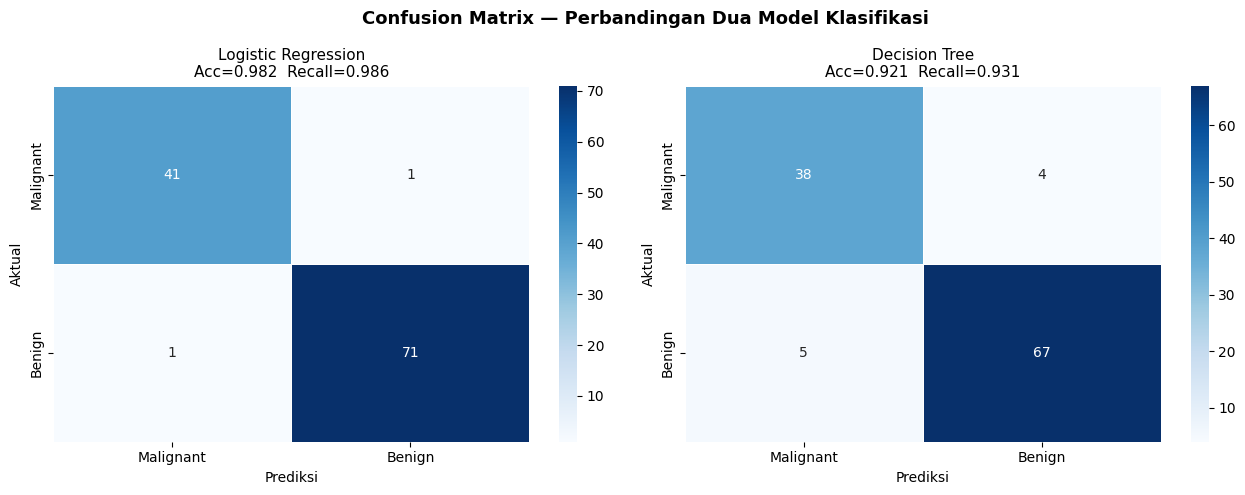

Plot tersimpan sebagai evaluasi_klasifikasi.png


In [23]:
# Visualisasi Confusion Matrix berdampingan
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
models_preds = [('Logistic Regression', y_pred_log),
                ('Decision Tree', y_pred_tree)]

for ax, (name, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'],
                linewidths=0.5, ax=ax)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    ax.set_title(f'{name}\nAcc={acc:.3f}  Recall={rec:.3f}', fontsize=11)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.suptitle('Confusion Matrix — Perbandingan Dua Model Klasifikasi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_klasifikasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan sebagai evaluasi_klasifikasi.png')

In [24]:
# Tabel perbandingan ringkas
compare = pd.DataFrame(results).T[['Accuracy','Precision','Recall','F1-Score','FN']]
compare = compare.round(4)
compare['FN'] = compare['FN'].astype(int)
compare.columns = ['Accuracy','Precision','Recall','F1-Score','False Neg (FN)']
print('=== Tabel Perbandingan Performa ===')
print(compare.to_string())
print()

# Model mana yang lebih baik dari segi Recall?
best_recall = compare['Recall'].idxmax()
print(f'Model dengan Recall tertinggi: {best_recall}  '
      f'(Recall = {compare.loc[best_recall, "Recall"]:.4f})')
print(f'Jumlah kanker terlewat (FN): '
      f'LR={results["Logistic Regression"]["FN"]}, '
      f'DT={results["Decision Tree"]["FN"]}')

=== Tabel Perbandingan Performa ===
                     Accuracy  Precision  Recall  F1-Score  False Neg (FN)
Logistic Regression    0.9825     0.9861  0.9861    0.9861               1
Decision Tree          0.9211     0.9437  0.9306    0.9371               5

Model dengan Recall tertinggi: Logistic Regression  (Recall = 0.9861)
Jumlah kanker terlewat (FN): LR=1, DT=5


## Langkah 6 — Analisis Komparatif: Mengapa Recall Paling Kritis?

### Perbandingan Performa Kedua Model

Hasil evaluasi pada 114 data test:

| Model | Accuracy | Precision | Recall | F1-Score | FN (kanker terlewat) |
|---|---|---|---|---|---|
| Logistic Regression | **98.2%** | **98.6%** | **98.6%** | **98.6%** | **1** |
| Decision Tree | 92.1% | 94.4% | 93.1% | 93.7% | 5 |

**Logistic Regression** unggul di seluruh metrik, dengan perbedaan paling krusial pada **Recall** (98.6% vs 93.1%) dan jumlah **False Negative** (hanya 1 kanker terlewat vs 5 pada Decision Tree).

### Mengapa Recall Lebih Penting dari Accuracy untuk Diagnosis Kanker?

**False Negative (FN) = kanker terlewat.** Skenario FN artinya pasien yang sesungguhnya menderita tumor ganas (*Malignant*) namun diprediksi model sebagai jinak (*Benign*). Konsekuensinya:
- Pasien tidak menerima penanganan medis yang diperlukan
- Tumor terus berkembang tanpa deteksi
- Keterlambatan pengobatan meningkatkan risiko kematian secara signifikan

**False Positive (FP) = alarm palsu.** Skenario FP artinya pasien sehat dikira memiliki tumor ganas. Konsekuensinya jauh lebih ringan: pasien menjalani pemeriksaan lanjutan (biopsi, MRI) yang tidak perlu, menimbulkan kecemasan sementara dan biaya tambahan — tetapi tidak mengancam jiwa.

**Kesimpulan pilihan model:** Pada domain diagnosis kanker, **Logistic Regression** lebih disarankan karena Recall-nya 98.6% (hanya 1 kasus terlewat dari 72 kasus Benign di test set). Decision Tree dengan Recall 93.1% melewatkan 5 kasus — dalam skenario klinis nyata, 4 pasien tambahan yang tidak terdeteksi bisa berakibat fatal. Accuracy yang tinggi saja bukan jaminan — model yang "aman" secara klinis adalah model yang meminimalkan False Negative, meski harus menerima lebih banyak False Positive (pemeriksaan lanjutan). Sesuai prinsip modul: *"Lebih baik over-diagnose daripada melewatkan kasus nyata."*

### Kapan Decision Tree Lebih Cocok?
Decision Tree lebih cocok saat **interpretabilitas** menjadi prioritas — misalnya saat dokter perlu menjelaskan alasan keputusan model kepada pasien atau regulator kesehatan. Pohon keputusan dapat dibaca sebagai aturan logis yang transparan, berbeda dengan Logistic Regression yang memerlukan pemahaman matematika sigmoid.

## Kesimpulan

Pipeline klasifikasi end-to-end berhasil dibangun pada dataset Breast Cancer Wisconsin (569 sampel, 30 fitur, target biner). Setelah preprocessing (stratified split 80:20 + StandardScaler anti-leakage), dua model dilatih dan dibandingkan:

**Logistic Regression** menggunakan fungsi Sigmoid untuk mengubah kombinasi linear fitur menjadi probabilitas, kemudian menerapkan threshold 0.5 untuk keputusan akhir. Model ini unggul pada seluruh metrik evaluasi berkat kemampuannya menangkap hubungan linear di ruang fitur terstandarisasi.

**Decision Tree** (max_depth=4, criterion='gini') membangun aturan if-else bertingkat menggunakan Gini Impurity sebagai kriteria pemilihan split. Tidak memerlukan scaling, mudah diinterpretasikan, namun sedikit lebih lemah dari LR pada dataset ini.

Temuan utama: **Recall adalah metrik paling kritis** untuk konteks diagnosis kanker. Logistic Regression (Recall=98.6%, FN=1) unggul atas Decision Tree (Recall=93.1%, FN=5) — selisih 4 kasus kanker terlewat yang dalam praktik klinis dapat berakibat fatal. Decision Tree tetap bernilai sebagai model cadangan yang dapat dijelaskan secara transparan kepada pemangku kepentingan non-teknis, dan fitur `worst radius` (importance=75.1%) terbukti menjadi pembeda utama tumor ganas vs jinak.